---

PROYECTO FINAL 

CASO DE NEGOCIO: SUBTES DE BS AS 🚇

---

Etapa 1: Exploración Visual de los Datos

In [1]:
# Importar las librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statistics

* Importación de los archivos CSV con Pandas

In [2]:
df_estaciones_accesibles = pd.read_csv('estaciones-accesibles.csv')

In [3]:
df_base_estaciones = pd.read_csv('BaseUnificadaEstaciones.csv')

In [4]:
df_lineas = pd.read_csv('lineas-de-subte.csv')

In [5]:
df_tarifas = pd.read_csv('registro-historico-del-precio-del-boleto.csv')

In [6]:
df_viajes = pd.read_csv('viajes_anual.csv')

In [7]:
df_historico_2014 = pd.read_csv('historico_2014.csv')

In [8]:
df_historico_2015 = pd.read_csv('historico_2015.csv')

In [9]:
df_historico_2016 = pd.read_csv('historico_2016.csv', encoding='latin-1')

In [10]:
df_historico_2017 = pd.read_csv('historico_2017.csv', encoding='latin-1')

In [11]:
df_historico_2018 = pd.read_csv('historico_2018.csv')

In [12]:
df_historico_2019 = pd.read_csv('historico_2019.csv')

In [13]:
df_historico_2020 = pd.read_csv('historico_2020.csv')

In [14]:
df_historico_2021 = pd.read_csv('historico_2021.csv')

* Análisis exploratorio de los datasets históricos (2014–2021)

In [ ]:
# Verificación de tamaño de los Dataset
print('Total de Filas y Columnas')
print('Historico 2014: ',df_historico_2014.shape)
print('Historico 2015: ',df_historico_2015.shape)
print('Historico 2016: ',df_historico_2016.shape)
print('Historico 2017: ',df_historico_2017.shape)
print('Historico 2018: ',df_historico_2018.shape)
print('Historico 2019: ',df_historico_2019.shape)
print('Historico 2020: ',df_historico_2020.shape)
print('Historico 2021: ',df_historico_2021.shape)
print('Base unificada de estaciones: ',df_base_estaciones.shape)
print('Estaciones accesibles: ',df_estaciones_accesibles.shape)
print('Registro historico del precio del boleto: ',df_tarifas.shape) 
print('viajes anual: ',df_viajes.shape) 
print('Lineas de subte: ',df_lineas.shape) 

Total de Filas y Columnas
Historico 2014:  (10857244, 11)
Historico 2015:  (10958582, 11)
Historico 2016:  (11542322, 11)
Historico 2017:  (11938476, 12)
Historico 2018:  (12136454, 11)
Historico 2019:  (12662343, 11)
Historico 2020:  (5781006, 10)
Historico 2021:  (8071680, 1)
Base unificada de estaciones:  (822363, 6)
Estaciones accesibles:  (93, 6)
Registro historico del precio del boleto:  (304, 4)
viajes anual:  (48, 3)
Lineas de subte:  (82, 3)


Se analiza 2019 como año representativo previo a la pandemia. 
Los resultados de `.info()` y `.describe()` son consistentes entre años.

In [57]:
# Estructura del dataset histórico (año representativo: 2019)
print('Información del dataset histórico 2019:')
df_historico_2019.info()

Información del dataset histórico 2019:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12662343 entries, 0 to 12662342
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   periodo          int64  
 1   fecha            object 
 2   desde            object 
 3   hasta            object 
 4   linea            object 
 5   molinete         object 
 6   estacion         object 
 7   pax_pagos        float64
 8   pax_pases_pagos  float64
 9   pax_franq        float64
 10  total            float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.0+ GB


In [58]:
# Primeras filas
df_historico_2019.head(5)

,periodo,fecha,desde,hasta,linea,molinete,estacion,pax_pagos,pax_pases_pagos,pax_franq,total
0,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Lima_N_Turn02,Lima,1.0,0.0,0.0,1.0
1,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Loria_N_Turn03,Loria,3.0,0.0,0.0,3.0
2,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_Q_HALL_Turn01,Plaza Miserere,3.0,0.0,0.0,3.0
3,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_S_Turn01,Plaza Miserere,6.0,0.0,0.0,6.0
4,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_S_Turn03,Plaza Miserere,10.0,0.0,0.0,10.0


In [59]:
# Estadísticas descriptivas
print('Descripción estadística - Histórico 2019:')
df_historico_2019.describe()

Descripción estadística - Histórico 2019:


,periodo,pax_pagos,pax_pases_pagos,pax_franq,total
count,1.266234e+07,1.266234e+07,1.266234e+07,1.266234e+07,1.266234e+07
mean,2.019066e+05,2.563776e+01,1.186783e-01,1.200694e+00,2.695714e+01
std,3.444613e+00,2.832257e+01,5.024237e-01,4.085881e+00,2.939805e+01
min,2.019010e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.019040e+05,5.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00
50%,2.019070e+05,1.600000e+01,0.000000e+00,0.000000e+00,1.700000e+01
75%,2.019100e+05,3.600000e+01,0.000000e+00,2.000000e+00,3.800000e+01
max,2.019120e+05,4.310000e+02,8.500000e+01,1.243800e+04,1.245900e+04


In [60]:
# Valores nulos por año
print('Nulos por dataset histórico:')
historicos = {
    '2014': df_historico_2014,
    '2015': df_historico_2015,
    '2016': df_historico_2016,
    '2017': df_historico_2017,
    '2018': df_historico_2018,
    '2019': df_historico_2019,
    '2020': df_historico_2020,
    '2021': df_historico_2021,
}
for año, df in historicos.items():
    total_nulos = df.isnull().sum().sum()
    print(f'  {año}: {total_nulos} valores nulos')

Nulos por dataset histórico:
  2014: 13840437 valores nulos
  2015: 0 valores nulos
  2016: 3812106 valores nulos
  2017: 0 valores nulos
  2018: 782126 valores nulos
  2019: 0 valores nulos
  2020: 18360 valores nulos
  2021: 0 valores nulos


In [61]:
# Duplicados por año
print('Duplicados por dataset histórico:')
for año, df in historicos.items():
    print(f'  {año}: {df.duplicated().sum()}')

Duplicados por dataset histórico:
  2014: 0
  2015: 0
  2016: 0
  2017: 0
  2018: 78203
  2019: 0
  2020: 9782
  2021: 0


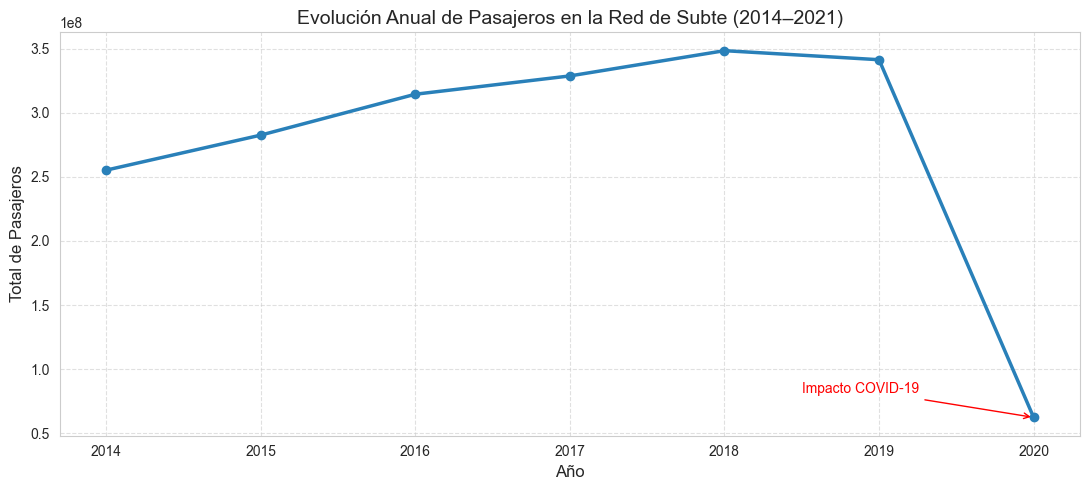

In [69]:
# Evolución anual de pasajeros totales (2014–2021)
# Usamos df_viajes que ya tiene el consolidado anual
# Agrupar pasajeros totales por año
df_viajes_anual = df_viajes[df_viajes['year'].between(2014, 2021)].groupby('year')['total'].sum().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(df_viajes_anual['year'], df_viajes_anual['total'],
         marker='o', color='#2980b9', linewidth=2.5)

# Anotación del impacto COVID
val_2020 = df_viajes_anual[df_viajes_anual['year'] == 2020]['total'].values
if len(val_2020) > 0:
    plt.annotate('Impacto COVID-19', xy=(2020, val_2020[0]),
                 xytext=(2018.5, val_2020[0] * 1.3),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.title('Evolución Anual de Pasajeros en la Red de Subte (2014–2021)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de Pasajeros', fontsize=12)
plt.xticks(df_viajes_anual['year'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

La caída abrupta en 2020 refleja el impacto de las restricciones por COVID-19 sobre la demanda del sistema. 

In [71]:
print(df_viajes['year'].unique())

[2013 2014 2015 2016 2017 2018 2019 2020]


ACLARACIÓN: El dataset `viajes_anual.csv` cubre el período 2014–2020, por tal motivo el gráfico muestra datos hasta dicho año. 
Los archivos históricos por molinete extienden el análisis hasta 2021.

* Análisis profundo sobre df_tarifas

In [42]:
# Estructura y tipos de datos
print('Información del dataset:')
df_tarifas.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   año         304 non-null    int64  
 1   mes_numero  304 non-null    int64  
 2   mes         304 non-null    object 
 3   precio      304 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 9.6+ KB


In [43]:
# Estadísticas descriptivas
print('Descripción estadística:')
df_tarifas.describe()

Descripción estadística:


,año,mes_numero,precio
count,304.000000,304.000000,304.000000
mean,2006.171053,6.447368,2.154112
std,7.327129,3.467510,3.000518
min,1994.000000,1.000000,0.450000
25%,2000.000000,3.000000,0.600000
50%,2006.000000,6.000000,0.700000
75%,2012.250000,9.000000,2.500000
max,2019.000000,12.000000,19.000000


In [44]:
# Identificación de valores nulos
df_tarifas.isnull().sum()

año           0
mes_numero    0
mes           0
precio        0
dtype: int64

In [45]:
# Verificación de duplicados
print('Duplicados:', df_tarifas.duplicated().sum())

Duplicados: 0


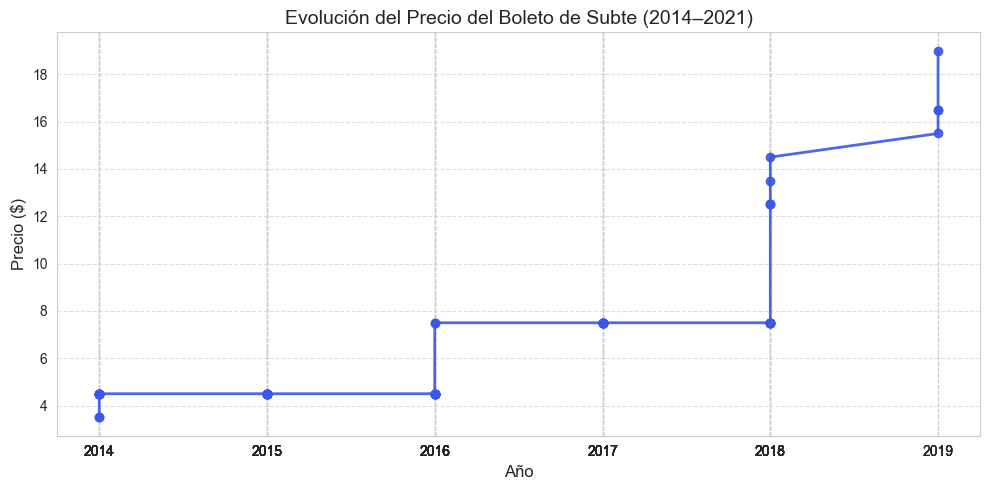

In [ ]:
# Evolución del precio del boleto (2014-2021)
df_tarifas_filtrado = df_tarifas[df_tarifas['año'] >= 2014]

plt.figure(figsize=(10, 5))
plt.plot(df_tarifas_filtrado['año'], df_tarifas_filtrado['precio'],
         marker='o', color="#3c56e7e6", linewidth=2)

plt.title('Evolución del Precio del Boleto de Subte (2014–2021)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.xticks(df_tarifas_filtrado['año'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Verificamos hasta donde llega la información del CSV de tarifas
df_tarifas.tail()

,año,mes_numero,mes,precio
299,2018,12,DICIEMBRE,14.5
300,2019,1,ENERO,15.5
301,2019,2,FEBRERO,16.5
302,2019,3,MARZO,16.5
303,2019,4,ABRIL,19.0


Aclaración Importante: En el archivo original la información está incompleta, ya que va desde enero 2014 hasta abril 2019 (tal como lo muestra el gráfico). Los datos que faltan fueron agregados en la Etapa 2, con MySQL.

Conclusión: El precio del boleto experimentó aumentos sostenidos entre 2014 y 2019. 
Esta variable será relevante al cruzarla con la demanda en etapas posteriores.

* Análisis profundo sobre df_viajes

In [49]:
# Primeras filas
df_viajes.head(5)

,year,LINEA,total
0,2013,A,26731478
1,2013,B,49458167
2,2013,C,27839180
3,2013,D,45532347
4,2013,E,11815541


In [50]:
# Estructura y tipos de datos
print('Información del dataset:')
df_viajes.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    48 non-null     int64 
 1   LINEA   48 non-null     object
 2   total   48 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.3+ KB


In [51]:
# Estadísticas descriptivas
print('Descripción estadística:')
df_viajes.describe()

Descripción estadística:


,year,total
count,48.000000,4.800000e+01
mean,2016.500000,4.372208e+07
std,2.315535,2.762894e+07
min,2013.000000,4.377480e+06
25%,2014.750000,1.898533e+07
50%,2016.500000,4.519574e+07
75%,2018.250000,6.474036e+07
max,2020.000000,9.201270e+07


In [21]:
df_viajes.isnull().sum()

year     0
LINEA    0
total    0
dtype: int64

In [52]:
# Verificación de duplicados
print('Duplicados:', df_viajes.duplicated().sum())        

Duplicados: 0


In [54]:
# Medidas de tendencia central
print('Media de viajes:', df_viajes['total'].mean())
print('Mediana de viajes:', df_viajes['total'].median())
print('Moda de viajes:', df_viajes['total'].mode()[0])

Media de viajes: 43722081.5
Mediana de viajes: 45195739.5
Moda de viajes: 4377480


In [55]:
# Medidas de dispersión
print('Rango:', df_viajes['total'].max() - df_viajes['total'].min())
print('Varianza:', df_viajes['total'].var())
print('Desviación estándar:', df_viajes['total'].std())

Rango: 87635219
Varianza: 763358300627203.6
Desviación estándar: 27628939.549450748


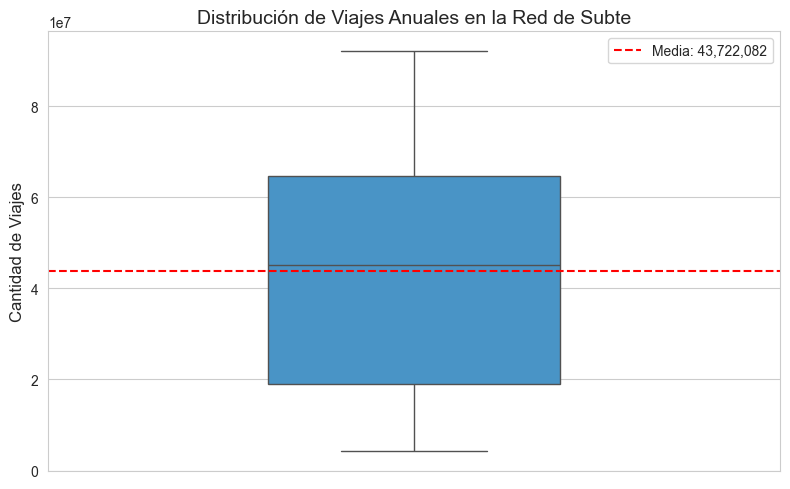

In [56]:
# Boxplot de viajes anuales
plt.figure(figsize=(8, 5))
sns.boxplot(y=df_viajes['total'], color='#3498db', width=0.4)

media_viajes = df_viajes['total'].mean()
plt.axhline(media_viajes, color='red', linestyle='--', linewidth=1.5,
            label=f'Media: {media_viajes:,.0f}')

plt.title('Distribución de Viajes Anuales en la Red de Subte', fontsize=14)
plt.ylabel('Cantidad de Viajes', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

* Análisis profundo sobre df_estaciones_accesibles

In [22]:
# Verificacion de las primeras 5 filas
df_estaciones_accesibles.head(5)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores
0,-58.436429,-34.618280,A,ACOYTE,2,2
1,-58.456710,-34.626667,A,CARABOBO,3,3
2,-58.421816,-34.611770,A,CASTRO BARROS,1,1
3,-58.392669,-34.609226,A,CONGRESO,2,2
4,-58.382232,-34.609100,A,LIMA,1,0


In [23]:
# Verificacion de las 2 ultimas filas

df_estaciones_accesibles.tail(2)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores
91,-58.402376,-34.594525,H,SANTA FE,9,7
92,-58.404732,-34.615242,H,VENEZUELA,4,3


In [24]:
# verificacion del tipo de dato de cada columna de nuestro DataFrame
df_estaciones_accesibles.dtypes

long                   float64
lat                    float64
linea                   object
estacion                object
escaleras_mecanicas      int64
ascensores               int64
dtype: object

In [25]:
# Obtencion del resumen de las características del conjunto de datos.
print('Descripcion estadistica:')
print(df_estaciones_accesibles.describe())

Descripcion estadistica:
            long        lat  escaleras_mecanicas  ascensores
count  93.000000  93.000000            93.000000   93.000000
mean  -58.407877 -34.605864             3.505376    1.247312
std     0.030478   0.017953             2.407523    1.646181
min   -58.486385 -34.641269             0.000000    0.000000
25%   -58.426789 -34.618280             2.000000    0.000000
50%   -58.402376 -34.604581             3.000000    0.000000
75%   -58.380715 -34.594525             5.000000    3.000000
max   -58.369930 -34.555642            11.000000    7.000000


Valores que nos muestra el metodo describe()
- count = conteo de los valores
- mean =  promedio
- std = desviacion estandar
- min = valor minimo
- 25% 50% 75% = cuartiles estadisticos
- max = valor maximo

In [ ]:
# Obtención de un resumen conciso del conjunto de datos
print('Informacion del dataset:')
df_estaciones_accesibles.info()

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   long                 93 non-null     float64
 1   lat                  93 non-null     float64
 2   linea                93 non-null     object 
 3   estacion             93 non-null     object 
 4   escaleras_mecanicas  93 non-null     int64  
 5   ascensores           93 non-null     int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 4.5+ KB


* Limpieza Preliminar

In [ ]:
# Identificación y conteo de valores nulos en el DataFrame
df_estaciones_accesibles.isnull().sum()

long                   0
lat                    0
linea                  0
estacion               0
escaleras_mecanicas    0
ascensores             0
dtype: int64

⬆ En el paso anterior, pudimos corroborar que nuestro Dataset, no tiene valores Nulos

In [28]:
# Verificación de duplicados
print(df_estaciones_accesibles.duplicated().sum())

0


In [ ]:
# Análisis de valores únicos en la columna "ascensores", con el método .value_counts()
print('Conteo de valores unicos:')
print(df_estaciones_accesibles['ascensores'].value_counts()) # acá utilice la técnica slicing

Conteo de valores unicos:
ascensores
0    51
3    18
2    10
1     7
4     4
6     2
7     1
Name: count, dtype: int64


In [ ]:
# Análisis de valores únicos en la columna "escaleras_mecánicas"
print('Conteo de valores unicos:')
print(df_estaciones_accesibles['escaleras_mecanicas'].value_counts()) # Nuevamente, utilice la técnica slicing

Conteo de valores unicos:
escaleras_mecanicas
2     24
3     16
1     15
4     13
5     10
6      6
10     4
9      2
0      1
11     1
8      1
Name: count, dtype: int64


* Análisis Descriptivo

Medidas de tendencia central (media, mediana, moda)

In [ ]:
# Cálculo de la media de escaleras mecánicas por cada linea de subte
promedio_escaleras_por_linea = df_estaciones_accesibles.groupby('linea')['escaleras_mecanicas'].mean()
print("Promedio de Escaleras Mecánicas por Línea:")
print(promedio_escaleras_por_linea.sort_values(ascending=False))

Promedio de Escaleras Mecánicas por Línea:
linea
H    5.583333
B    3.631579
E    3.578947
D    3.529412
C    2.545455
A    2.266667
Name: escaleras_mecanicas, dtype: float64


In [ ]:
# Análisis de la Mediana de ascensores
mediana = statistics.median(df_estaciones_accesibles['ascensores'])
print('La mediana de ascensores es de', mediana)

La mediana de ascensores es de 0


In [ ]:
# Análisis de la Moda de escaleras mecánicas. 
try:
    mode=statistics.mode(df_estaciones_accesibles['escaleras_mecanicas'])
    print('La moda de escaleras_mecanicas en la red de subtes de Bs As es:',mode)
except statistics.StatisticsError as e:
    print(f'No hay una unica moda: {e}')
# Esta medida nos sirve para comprender cual es el valor que aparece con mayor frecuencia en nuestro conjunto de datos.

La moda de escaleras_mecanicas en la red de subtes de Bs As es: 2


* Medidas de dispersion (rango, varianza, desviación estándar), y correlación

In [ ]:
# Rango estadístico
# Hice el calculo del valor máximo y mínimo de escaleras encontradas en una sola estación y luego obtuve la diferencia entre ambos.
range_value=max(df_estaciones_accesibles['escaleras_mecanicas'])-min(df_estaciones_accesibles['escaleras_mecanicas'])
print(max(df_estaciones_accesibles['escaleras_mecanicas']))
print(min(df_estaciones_accesibles['escaleras_mecanicas']))
print(range_value)

11
0
11


In [35]:
# Varianza
# Mide cuánto se dispersan los valores individuales del número de escaleras mecánicas con respecto a la media de ese número.
variance=statistics.variance(df_estaciones_accesibles['escaleras_mecanicas'])
print(variance)

5.796166432912576


In [ ]:
# Desviación estándar
std_dev=statistics.stdev(df_estaciones_accesibles['escaleras_mecanicas'])
print(std_dev) # Da como resultado la raiz cuadrada de la varianza (punto anterior)

2.407522883154504


In [ ]:
# Cálculo de correlación de Pearson
correlacion = df_estaciones_accesibles['escaleras_mecanicas'].corr(
    df_estaciones_accesibles['ascensores']
)

print(f"Coeficiente de Correlación (Escaleras vs. Ascensores): {correlacion:.4f}")

Coeficiente de Correlación (Escaleras vs. Ascensores): 0.6044


* Visualización de Patrones y Relaciones

================= Gráfico de Dispersión =================

Correlación entre Escaleras Mecánicas y Ascensores:

El objetivo de esta correlación es determinar si las estaciones que están más equipadas para gestionar el flujo rápido de pasajeros (muchas escaleras mecánicas) son también las que priorizan la accesibilidad universal (muchos ascensores). Se busca comprender si existe una relación lineal positiva entre la cantidad de escaleras mecánicas y la cantidad de ascensores en una estación.

Significado del Resultado:

- Correlación Positiva Alta (cercana a 1): Indica que las estaciones que invierten fuertemente en una infraestructura (ej., 6 escaleras) también lo hacen en la otra (ej., 3 ascensores). Muestra una estrategia de equipamiento integral.
- Correlación Baja o Negativa (cercana a 0 o -1): Sugiere que la inversión es segregada. Por ejemplo, algunas estaciones se centran solo en el flujo rápido (muchas escaleras, pocos o ningún ascensor)

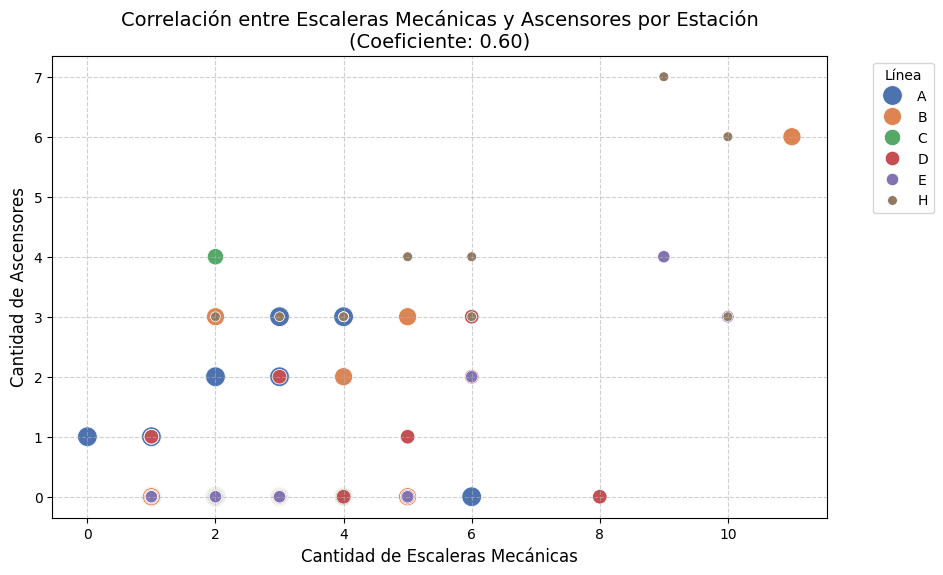

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='escaleras_mecanicas',
    y='ascensores',
    data=df_estaciones_accesibles,
    hue='linea',  # Usa la línea como color para añadir contexto
    size='linea',
    sizes=(50, 200),
    palette='deep'
)

# Añadir etiquetas y título
plt.title(f'Correlación entre Escaleras Mecánicas y Ascensores por Estación\n(Coeficiente: {correlacion:.2f})', fontsize=14)
plt.xlabel('Cantidad de Escaleras Mecánicas', fontsize=12)
plt.ylabel('Cantidad de Ascensores', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Línea', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar el gráfico
plt.show()

================= Heatmap =================


Interpretación e Insights Clave 📊

Este tipo de gráfico facilita la identificación de los siguientes insights importantes:

1) Correlación Infraestructura (Escaleras vs Ascensores): 

- Mira el valor en la intersección de escaleras_mecanicas y ascensores. Este valor confirma el análisis de correlación simple realizado anteriormente.
- Insight: Si el valor es alto y positivo (cercano a 1), significa que la inversión en infraestructura de flujo y accesibilidad está altamente coordinada. Si es bajo, significa que muchas estaciones tienen muchas escaleras, pero pocos ascensores (o viceversa), confirmando una disparidad en la estrategia de equipamiento.

2) Correlación Geográfica (Lat vs Infraestructura):

- Mira la fila/columna de lat (latitud) contra escaleras_mecanicas o ascensores.
- Los valores de latitud en Buenos Aires se vuelven menos negativos (más cercanos a cero) a medida que te mueves hacia el Norte.
- Insight: Si existe una correlación negativa entre lat y escaleras_mecanicas, significa que las estaciones ubicadas más al Sur (latitud más negativa) tienden a tener más escaleras. Si la correlación es positiva, la infraestructura se concentra en las estaciones del Norte. 

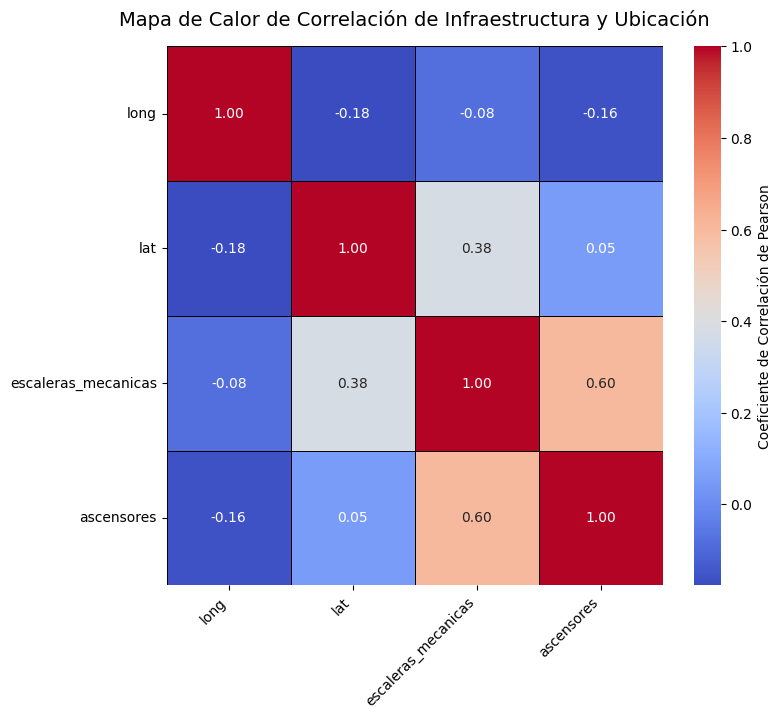

In [ ]:
# Selección de variables numéricas para el Heatmap
# Incluimos latitud y longitud, ya que también son variables numéricas
numeric_cols = ['long', 'lat', 'escaleras_mecanicas', 'ascensores']
df_corr = df_estaciones_accesibles[numeric_cols].copy()

# Calcular la Matriz de Correlación de Pearson
correlation_matrix = df_corr.corr(method='pearson')

# Crear el Heatmap
plt.figure(figsize=(8, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,         # Muestra el valor de correlación en cada celda
    fmt=".2f",          # Formato de dos decimales
    cmap='coolwarm',    # Esquema de color: rojo para negativo, azul para positivo
    linewidths=0.5,     # Espacio entre celdas
    linecolor='black',
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

# Personalización
plt.title('Mapa de Calor de Correlación de Infraestructura y Ubicación', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

================= Histograma =================

Infraestructura de escaleras mecánicas en las estaciones del Subte de Buenos Aires

Este tipo de grafico nos muestra la frecuencia con la que ocurren diferentes valores en nuestro conjunto de datos numéricos.

Analisis realizado para comprender como está repartida la infraestructura de escaleras mecánicas en las estaciones del Subte de Buenos Aires.

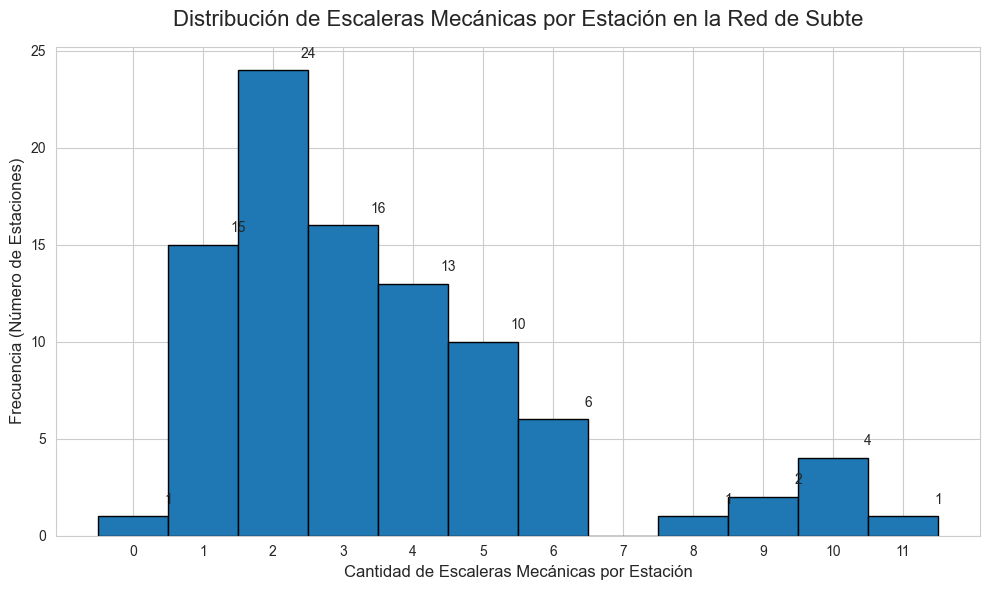

In [ ]:
# Preparación para la Visualización
sns.set_style("whitegrid")

# Definición de los 'bins' (barras) para el histograma.
# Esto asegura que cada número entero de escaleras (0, 1, 2, etc.) tenga su propia barra.
max_escaleras = df_estaciones_accesibles['escaleras_mecanicas'].max()
bins = np.arange(0, max_escaleras + 2) # Crea bins hasta el máximo + 1

# Creación del Histograma
plt.figure(figsize=(10, 6))

plt.hist(
    df_estaciones_accesibles['escaleras_mecanicas'],
    bins=bins,
    edgecolor='black',  # Borde para distinguir las barras
    color='#1f77b4',    # Color de las barras
    align='left'        # Alinea el bin para que el valor entero quede en el borde izquierdo
)

# Personalización del Gráfico
plt.title('Distribución de Escaleras Mecánicas por Estación en la Red de Subte', fontsize=16, pad=15)
plt.xlabel('Cantidad de Escaleras Mecánicas por Estación', fontsize=12)
plt.ylabel('Frecuencia (Número de Estaciones)', fontsize=12)

# Asegurarse de que el eje X muestre ticks enteros
plt.xticks(np.arange(0, max_escaleras + 1))

# Añadir el conteo exacto sobre cada barra 
for i in range(len(bins) - 1):
    # Filtra los datos que caen en el rango de cada bin
    count = df_estaciones_accesibles['escaleras_mecanicas'].apply(
        lambda x: True if bins[i] <= x < bins[i+1] else False
    ).sum()
    
    if count > 0:
        # Coloca el texto en el centro de la barra
        plt.text(bins[i] + 0.5, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

# Ajustar el espacio para eliminar el sobrante de arriba
plt.tight_layout() 

plt.show()


Interpretación de los Resultados

Barra Alta en la Izquierda (Frecuencia Máxima):

- Una barra muy alta en los valores bajos del Eje X (probablemente en 0, 1, o 2 escaleras).

  Insight: La Moda (el valor más común) de la red es tener pocas o ninguna escalera mecánica. Esto te indica que la mayoría de las estaciones tienen una infraestructura de flujo muy básica.

Larga Cola hacia la Derecha (Asimetría Positiva):

- Las barras se vuelven muy cortas a medida que te mueves hacia los valores altos del Eje X (ej., 6, 8, 10, 11 escaleras).

  Insight: Esto confirma la asimetría positiva (o sesgo a la derecha) que mencionamos. El número de estaciones con una alta cantidad de escaleras (como 8 a 11) es muy bajo. Son la minoría, pero son responsables de elevar el promedio.

Conclusión 

El histograma es la prueba visual de la desigualdad de la infraestructura. Nos muestra que el sistema de subte es desigual:

* La Mayoría opera con una infraestructura mínima (barras altas a la izquierda).

* La Minoría, unas pocas estaciones clave (cabeceras, combinaciones) tienen una infraestructura masiva (barras cortas a la derecha).

Las estaciones con mínima infraestructura (la mayoría) pueden convertirse en cuellos de botella si tienen una demanda alta.

================= BOXPLOT =================


El boxplot divide los datos en cuartiles y muestra cómo están dispersos, permitiendo identificar la tendencia central y la presencia de valores extremos.

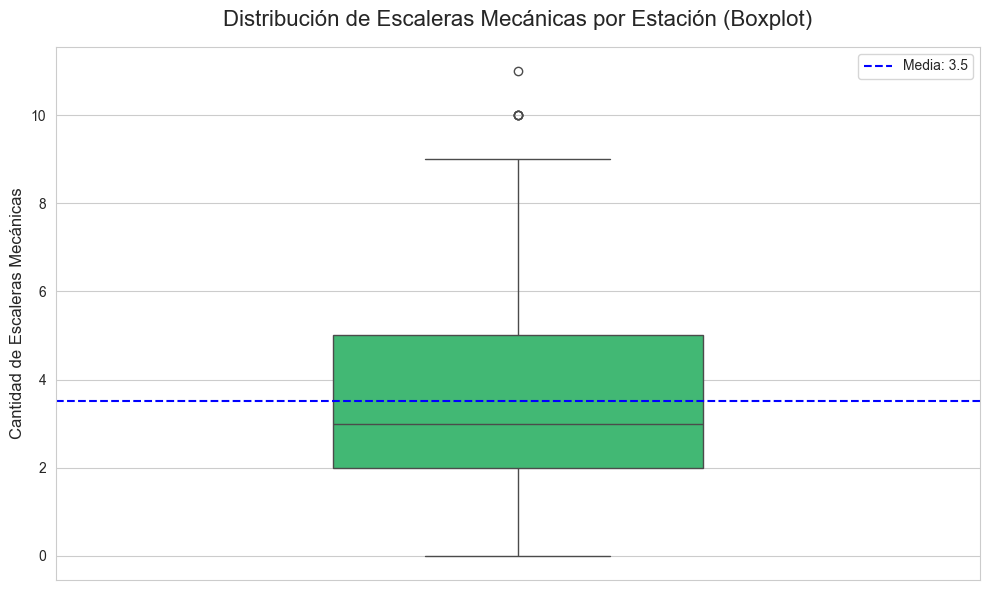

In [41]:
# Preparación para la Visualización
sns.set_style("whitegrid")

# Define el tamaño de la figura (figsize)
plt.figure(figsize=(10, 6))

# Creación del Boxplot
sns.boxplot(
    y=df_estaciones_accesibles['escaleras_mecanicas'],
    color='#2ecc71', 
    width=0.4
)

# Personalización y Estadísticas
# Calcular estadísticas para incluirlas en el gráfico
media = df_estaciones_accesibles['escaleras_mecanicas'].mean()
mediana = df_estaciones_accesibles['escaleras_mecanicas'].median()

plt.title('Distribución de Escaleras Mecánicas por Estación (Boxplot)', fontsize=16, pad=15)
plt.ylabel('Cantidad de Escaleras Mecánicas', fontsize=12)

# Mostrar la media 
plt.axhline(media, color='blue', linestyle='--', linewidth=1.5, label=f'Media: {media:.1f}')
plt.legend(loc='upper right')

# Eliminar espacio sobrante
plt.tight_layout() 

plt.show()

Conclusión:

1. Concentración de la Baja Infraestructura: Una caja y una mediana ubicadas en valores bajos del gráfico (cercanas a 0, 1 o 2) prueban que la tendencia central de la red es tener equipamiento limitado. Esto sugiere que la fluidez del pasajero depende principalmente de escaleras fijas en la mayoría de las estaciones.

2. Disparidad: La mediana no está centrada en la caja y los bigotes no son simétricos. El equipamiento está desigualmente distribuido.

3. Identificación de Estaciones Hub: Los outliers son críticos. Estas son las estaciones que sobresalen en equipamiento. Si estas estaciones se alinean con las de mayor tráfico (que analizarás con tu próximo archivo), demuestran ser hubs de transporte eficientes, pero también son las excepciones a la regla de la red.

Podemos señalar que el 75% de la red (todo lo que queda por debajo del Q3) necesita ser evaluado para una posible mejora de infraestructura, especialmente si tienen alto tráfico.

---
## Conclusión General — Etapa 1: Exploración Visual de los Datos

A lo largo de esta etapa se realizó un análisis exploratorio completo sobre los datasets 
del sistema de Subtes de Buenos Aires (2014–2021), abarcando infraestructura, accesibilidad, 
tarifas y demanda de pasajeros.

### Principales hallazgos

**Infraestructura y accesibilidad:**
- La red presenta una distribución desigual de escaleras mecánicas y ascensores. 
  La mayoría de las estaciones opera con equipamiento mínimo (moda = 0), mientras que 
  un grupo reducido de estaciones hub concentra la mayor parte de la infraestructura.
- La correlación entre escaleras mecánicas y ascensores es positiva pero moderada, 
  lo que sugiere que la inversión en flujo de pasajeros y accesibilidad universal 
  no siempre va de la mano.

**Demanda de pasajeros:**
- El sistema experimentó crecimiento sostenido entre 2014 y 2018, alcanzando su pico 
  de demanda ese año.
- En 2020, la pandemia de COVID-19 provocó una caída abrupta en la cantidad de pasajeros, 
  siendo el dato más significativo del período analizado.

**Tarifas:**
- El precio del boleto aumentó de forma continua entre 2014 y 2021, lo que plantea 
  interrogantes sobre su impacto en la demanda, a explorar en etapas posteriores.

### Limitaciones identificadas
- El dataset 'viajes_anual.csv' cubre hasta 2020, mientras que los históricos por 
  molinete llegan hasta 2021.
- El dataset 'registro-historico-del-precio-del-boleto' va desde enero de 2014 hasta abril de 2019.
- Los archivos históircos presentan valores en 'NA', tratados como nulos 
  en la exploración.

### Próximos pasos — Etapa 2
Con la exploración completada, la siguiente etapa se enfocará en la limpieza profunda 
y transformación de los datos, incluyendo normalización de columnas, unificación de 
los históricos y preparación del dataset para el modelado.